In [603]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from numba import njit
from numba.experimental import jitclass
from numba.types import int32, float64
from makeImage import *
from qc import *
import graphviz

# Hopfield Network

In [713]:
hopfield_spec = [
    ("n", int32),
    ("s", float64[:]),
    ("b", float64[:]),
    ("W", float64[:, :]),
]


@jitclass(hopfield_spec)
class Hopfield:
    def __init__(self, n):
        self.n = n
        self.s = np.random.random(n)
        self.s[self.s < 0.5] = -1.0
        self.s[self.s >= 0.5] = 1.0
        self.b = np.random.uniform(-1, 1, n)
        self.W = np.triu(np.random.uniform(-1, 1, n**2).reshape(n, n), k=1)
        self.W = self.W + self.W.T

    def get_energy(self):

        s = self.s
        W = self.W
        n = self.n
        b = self.b
        e = 0
        for i in range(n):

            for j in range(i, n):

                e -= W[i, j] * s[i] * s[j]

            e += b[i] * s[i]

        return e

    def update(self):

        W = self.W
        b = self.b
        s = self.s
        n = self.n

        for i in range(n):
            s[i] = np.sign(np.dot(W[i, :], s) - b[i])

        return None

    def single_update(self, i):

        W = self.W
        b = self.b
        s = self.s
        n = self.n

        e0 = self.get_energy()
        s[i] *= -1
        e1 = self.get_energy()
        s[i] *= -1

        if e1 < e0:

            return True

        return False

    def iterate(self, niter):

        energies = np.zeros(niter)
        last_state = np.copy(self.s)

        for ni in range(niter):

            energies[ni] = self.get_energy()
            self.update()

            if (self.s == last_state).all():

                if ni < niter - 1:

                    energies[ni + 1] = self.get_energy()

                break

            last_state = np.copy(self.s)

        return energies[: ni + 2]

    def train(self, dataset):

        m = dataset.shape[0]
        self.W = np.zeros((self.n, self.n))
        for data in dataset:

            self.W += np.outer(data, data)

        self.W /= m

        return None

    def set_state(self, state):

        self.s = state.copy()

        return None

    def get_state(self):

        return self.s

    def state_to_int(self, state):
        state[state < 0] = 0
        shift = 1 << np.arange(state.shape[0] - 1, -1, -1)
        shift = shift.astype(np.float64)

        return np.int32(np.sum(state * shift))

    def int_to_state(self, n, i):

        state = np.zeros(n)
        for j in range(n):

            state[j] = 2 * (i & (1 << j) != 0) - 1

        return state[::-1]


@njit(fastmath=True)
def generate_data(p, n):

    data = np.zeros((p, n))

    for i in range(p):

        data[i] = np.random.random(n)
        data[i][data[i] < 0.5] = -1.0
        data[i][data[i] >= 0.5] = 1.0

    return data


@njit(fastmath=True)
def hamming_distance(x, y):

    return np.sum(x != y)


@njit(fastmath=True)
def perturb_data(data, k):

    data = data.flatten()
    n = data.shape[0]
    idx = np.random.choice(n, k, replace=False)
    data[idx] *= -1

    return data

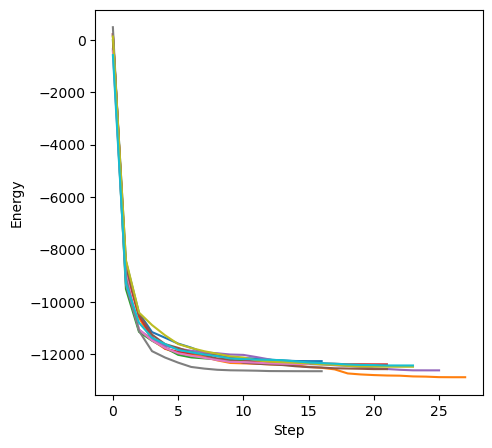

In [749]:
n = 1000
niter = 100
N = 10
fig, ax = plt.subplots(figsize=(5, 5))
for i in range(N):

    h = Hopfield(n)
    energies = h.iterate(niter)
    assert np.all(np.diff(energies) <= 0)
    ax.plot(energies)

ax.set_xlabel("Step")
ax.set_ylabel("Energy")
plt.show()

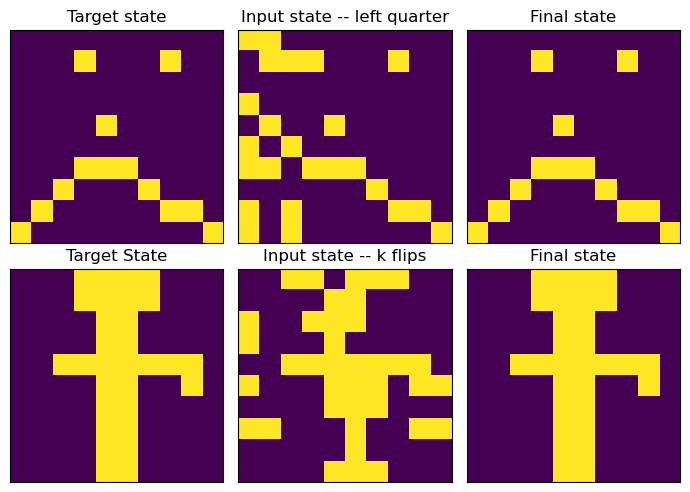

In [22]:
niter = 100
dataset = np.array([MakeFace().flatten(), MakeTree().flatten()])
n = dataset[0].shape[0]
h = Hopfield(n)
h.train(dataset)

test = MakeFace()
test[:, :3] = np.random.choice([-1, 1], (10, 3))
test = test.flatten()

fig, ax = plt.subplots(2, 3, figsize=(7, 5))

h.set_state(test)
energies = h.iterate(niter)
res = h.get_state().reshape(10, 10)

ax[0, 0].imshow(MakeFace(), vmin=-1, vmax=1)
ax[0, 0].set_title("Target state")
ax[0, 0].set_xticks([])
ax[0, 0].set_yticks([])

ax[0, 1].imshow(test.reshape(10, 10), vmin=-1, vmax=1)
ax[0, 1].set_title("Input state -- left quarter")
ax[0, 1].set_xticks([])
ax[0, 1].set_yticks([])

ax[0, 2].imshow(res, vmin=-1, vmax=1)
ax[0, 2].set_title("Final state")
ax[0, 2].set_xticks([])
ax[0, 2].set_yticks([])


test = perturb_data(MakeTree(), k=20)
h.set_state(test)
energies = h.iterate(niter)
res = h.get_state().reshape(10, 10)

ax[1, 0].imshow(MakeTree(), vmin=-1, vmax=1)
ax[1, 0].set_title("Target State")
ax[1, 0].set_xticks([])
ax[1, 0].set_yticks([])

ax[1, 1].imshow(test.reshape(10, 10), vmin=-1, vmax=1)
ax[1, 1].set_title("Input state -- k flips")
ax[1, 1].set_xticks([])
ax[1, 1].set_yticks([])

ax[1, 2].imshow(res, vmin=-1, vmax=1)
ax[1, 2].set_title("Final state")
ax[1, 2].set_xticks([])
ax[1, 2].set_yticks([])

fig.tight_layout()
plt.show()

In [24]:
n = 100
ps = np.arange(1, n + 1)
ks = np.arange(1, n + 1)
Ds = np.zeros((n, n))
n_ave = 10
niter = 100
for i, p in enumerate(ps):
    dataset = generate_data(p, n)
    h = Hopfield(n)
    h.train(dataset)

    for j, k in enumerate(ks):

        average_distance = 0
        for _ in range(n_ave):

            index = np.random.choice(p)
            data = dataset[index]
            perturbed = perturb_data(data, k)
            h.set_state(perturbed)
            energies = h.iterate(niter)
            res = h.get_state()
            D = hamming_distance(data, res)
            average_distance += D

        Ds[i, j] = average_distance / n_ave

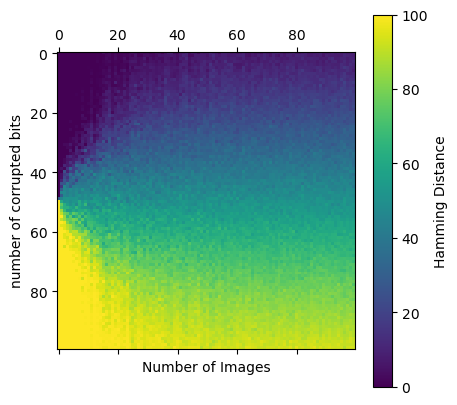

In [25]:
plt.matshow(Ds.T)
plt.xlabel("Number of Images")
plt.ylabel("number of corrupted bits")
plt.colorbar(label="Hamming Distance")
plt.show()

In [733]:
n = 6
h = Hopfield(n)
state1 = 47
state2 = 44
m0 = h.int_to_state(n, state1)
m1 = h.int_to_state(n, state2)
dataset = np.array([m0, m1])
h.train(dataset)  # train hopfield on 2 memories

graph = {}

#  For all possible starting states, iterate once and find the next state for each node
for i in range(2**n):

    state = h.int_to_state(n, i)  # convert current int to state
    h.set_state(state.copy())  # set the state of the hopfield to the current state
    # energies = h.iterate(1)  # iterate once
    # new_state = h.get_state()  # get the new state
    graph[i] = []

    for node_idx in range(n):

        # if new_state[node_idx] != state[node_idx]:

        if h.single_update(node_idx):

            tmp = np.copy(state)
            tmp[node_idx] *= -1  # new_state[node_idx]
            j = h.state_to_int(tmp)

            graph[i].append(j)

dot = graphviz.Digraph()
for initState in graph.keys():

    if initState == state1 or initState == state2:
        dot.node(str(initState), style="filled", fillcolor="red")

    else:
        dot.node(str(initState))
    for targetState in graph[initState]:
        dot.edge(str(initState), str(targetState))

dot.render("hopfield", format="png", cleanup=True)

'hopfield.png'

Text(0, 0.5, 'Energy')

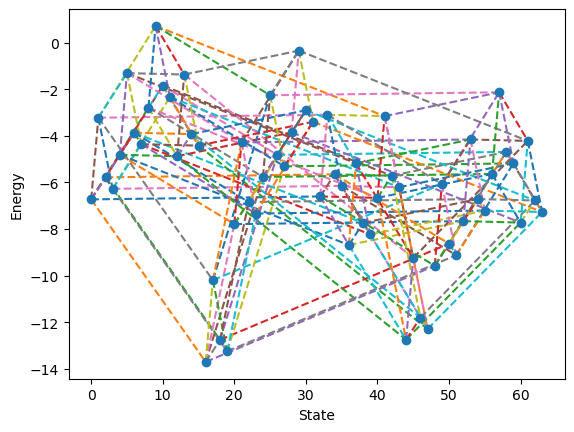

In [747]:
h = Hopfield(n)
h.train(dataset)


Egraph = {}
Es = np.zeros((2**n, 2))
for i in range(2**n):
    h.s = h.int_to_state(n, i)
    Ei = h.get_energy()
    Egraph[i] = Ei
    Es[i] = np.array([i, Ei])


for i in range(2**n):

    state = h.int_to_state(n, i)

    for node_idx in range(n):

        tmp = np.copy(state)
        tmp[node_idx] *= -1
        j = h.state_to_int(tmp)
        if i < j:
            plt.plot([i, j], [Egraph[i], Egraph[j]], "--")

plt.plot(Es[:, 0], Es[:, 1], "o", color="tab:blue")
plt.xlabel("State")
plt.ylabel("Energy")

# Restricted Boltzmann Machines

In [514]:
rbm_spec = [
    ("nv", int32),
    ("nh", int32),
    ("v", float64[:]),
    ("h", float64[:]),
    ("W", float64[:, :]),
    ("a", float64[:]),
    ("b", float64[:]),
]


@jitclass(rbm_spec)
class RBM:

    def __init__(self, nv, nh):

        np.random.seed(0)
        self.nv = nv
        self.nh = nh
        self.h = np.random.rand(nh)
        h_mask = self.h < 0.5
        self.h[h_mask] = -1
        self.h[~h_mask] = 1
        self.v = np.random.rand(nv)
        v_mask = self.v < 0.5
        self.v[v_mask] = -1
        self.v[~v_mask] = 1
        self.W = np.random.uniform(-1, 1, nv * nh).reshape(nv, nh)
        self.a = np.random.uniform(-1, 1, nv)
        self.b = np.random.uniform(-1, 1, nh)

    def get_energy(self):

        W = self.W
        v = self.v
        h = self.h

        e = -np.dot(v, np.dot(W, h)) - np.dot(v, self.a) - np.dot(h, self.b)

        return e

    def sample_h_given_v(self):

        rcheck = np.random.rand(self.nh)
        ms = np.dot(self.W.T, self.v) + self.b
        numerator = np.exp(ms)
        probs = numerator / (numerator + np.exp(-ms))
        self.h = 2 * (rcheck <= probs) - 1.0

        return None

    def sample_v_given_h(self):

        rcheck = np.random.rand(self.nv)
        ms = np.dot(self.W, self.h) + self.a
        numerator = np.exp(ms)
        probs = numerator / (numerator + np.exp(-ms))
        self.v = 2 * (rcheck <= probs) - 1.0

        return None

    def sample_joint(self, k):

        for _ in range(k):

            self.sample_h_given_v()
            self.sample_v_given_h()

        return None

    def state_to_int(self, state):
        state[state < 0] = 0
        shift = 1 << np.arange(state.shape[0] - 1, -1, -1)
        shift = shift.astype(np.float64)

        return np.int32(np.sum(state * shift))

    def h_to_int(self):

        return self.state_to_int(self.h.copy())

    def v_to_int(self):

        return self.state_to_int(self.v.copy())

    def int_to_state(self, n, i):

        state = np.zeros(n)
        for j in range(n):

            state[j] = 2 * (i & (1 << j) != 0) - 1

        return state[::-1]

    def h_given_v(self, niter):

        probs = np.zeros(2**self.nh)

        for _ in range(niter):

            self.sample_h_given_v()
            probs[self.h_to_int()] += 1

        return probs / niter

    def h_given_v_theory(self):

        probs = np.zeros(2**self.nh)

        for i in range(2**self.nh):

            self.h = self.int_to_state(self.nh, i)
            probs[i] = np.exp(-self.get_energy())

        return probs / np.sum(probs)

    def v_given_h(self, niter):

        probs = np.zeros(2**self.nv)

        for _ in range(niter):

            self.sample_v_given_h()
            probs[self.v_to_int()] += 1

        return probs / niter

    def v_given_h_theory(self):

        probs = np.zeros(2**self.nv)

        for i in range(2**self.nv):

            self.v = self.int_to_state(self.nv, i)
            probs[i] = np.exp(-self.get_energy())

        return probs / np.sum(probs)

    def joint(self, niter, k):

        probs = np.zeros((2**self.nv, 2**self.nh))

        for _ in range(niter):

            self.sample_joint(k)
            probs[self.v_to_int(), self.h_to_int()] += 1

        return probs / niter

    def joint_theory(self):

        probs = np.zeros((2**self.nv, 2**self.nh))

        for i in range(2**self.nv):

            for j in range(2**self.nh):

                self.v = self.int_to_state(self.nv, i)
                self.h = self.int_to_state(self.nh, j)
                probs[i, j] = np.exp(-self.get_energy())

        return probs / np.sum(probs)

    def pv(self, niter, k):

        probs = np.sum(self.joint(niter, k), axis=1)

        return probs

    def pv_theory(self):

        probs = np.sum(self.joint_theory(), axis=1)

        return probs

    def ph(self, niter, k):

        probs = np.sum(self.joint(niter, k), axis=0)

        return probs

    def ph_theory(self):

        probs = np.sum(self.joint_theory(), axis=0)

        return probs

    def get_state(self):

        return self.v, self.h

    def joint_to_int(self, joint):

        nv = self.nv
        nh = self.nh
        joint_probs = np.zeros(2 ** (nv + nh))
        for i in range(2**nv):

            for j in range(2**nh):

                v = self.int_to_state(nv, i)
                h = self.int_to_state(nh, j)
                joint_state = np.concatenate((v, h))
                joint_probs[self.state_to_int(joint_state)] = joint[i, j]

        return joint_probs

    def train(self, alpha, nepoch, batch_size, data, k):

        indices = np.arange(data.shape[0])
        data_states = np.zeros((data.shape[0], self.nv), dtype=np.float64)

        for i, num in enumerate(data):

            data_states[i] = self.int_to_state(self.nv, num).astype(np.float64)

        for e in range(nepoch):

            dW = np.zeros((self.nv, self.nh))
            da = np.zeros(self.nv)
            db = np.zeros(self.nh)
            self.v = self.int_to_state(self.nv, data[e]).astype(np.float64)

            np.random.shuffle(indices)

            for i in range(batch_size):

                idx = indices[i]
                self.v = data_states[idx]
                self.sample_h_given_v()
                dW -= np.outer(self.v, self.h)
                da -= self.v
                db -= self.h

                self.sample_joint(k)
                dW += np.outer(self.v, self.h)
                da += self.v
                db += self.h

            self.W -= alpha * dW / batch_size
            self.a -= alpha * da / batch_size
            self.b -= alpha * db / batch_size

        return None

In [506]:
niter = 100000
nv = 5
nh = 2

test = RBM(nv, nh)
h_ints = np.arange(2**nh)
v_ints = np.arange(2**nv)
joint_ints = np.arange(2 ** (nv + nh))

joint = test.joint(niter, 20)
joint_probs = test.joint_to_int(joint)

joint_theory = test.joint_theory()
joint_theory_probs = test.joint_to_int(joint_theory)


pv = np.sum(joint, axis=1)
pv_theory = np.sum(joint_theory, axis=1)

ph = np.sum(joint, axis=0)
ph_theory = np.sum(joint_theory, axis=0)

v_given_h = joint / ph
v_given_h_theory = joint_theory / ph_theory

h_given_v = joint.T / pv
h_given_v_theory = joint_theory.T / pv_theory

(128,)


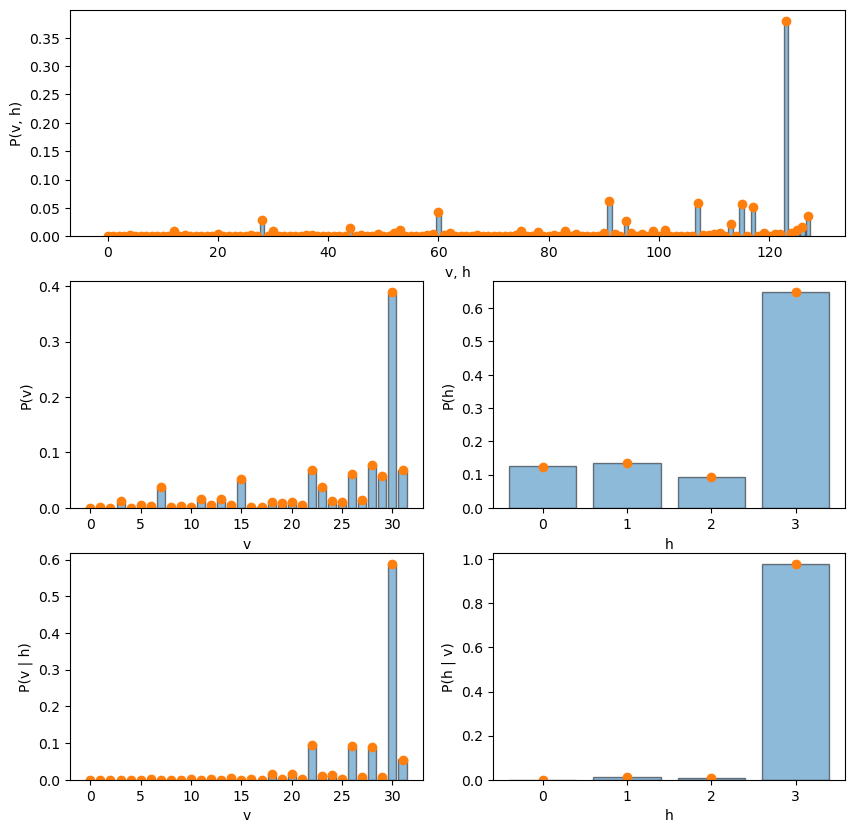

In [507]:
fig = plt.figure()
gs = fig.add_gridspec(3, 2)
ax1 = fig.add_subplot(gs[0, :])
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[1, 1])
ax4 = fig.add_subplot(gs[2, 0])
ax5 = fig.add_subplot(gs[2, 1])

ax1.bar(joint_ints, joint_probs, alpha=0.5, label="MC", edgecolor="black")
ax1.scatter(joint_ints, joint_theory_probs, color="tab:orange", label="Theory")
ax1.set_xlabel("v, h")
ax1.set_ylabel("P(v, h)")

ax2.bar(v_ints, pv, alpha=0.5, label="MC", edgecolor="black")
ax2.scatter(v_ints, pv_theory, color="tab:orange", label="Theory")
ax2.set_xlabel("v")
ax2.set_ylabel("P(v)")

ax3.bar(h_ints, ph, alpha=0.5, label="MC", edgecolor="black")
ax3.scatter(h_ints, ph_theory, color="tab:orange", label="Theory")
ax3.set_xlabel("h")
ax3.set_ylabel("P(h)")

ax4.bar(v_ints, v_given_h[:, -1], alpha=0.5, label="MC", edgecolor="black")
ax4.scatter(v_ints, v_given_h_theory[:, -1], color="tab:orange", label="Theory")
ax4.set_xlabel("v")
ax4.set_ylabel("P(v | h)")

ax5.bar(h_ints, h_given_v[:, -2], alpha=0.5, label="MC", edgecolor="black")
ax5.scatter(h_ints, h_given_v_theory[:, -2], color="tab:orange", label="Theory")
ax5.set_xlabel("h")
ax5.set_ylabel("P(h | v)")

fig.set_size_inches(10, 10)
plt.show()

In [601]:
niter = 100000
sample_size = 100000
batch_size = 64
alpha = 0.1
k = 1
nv = 3
nh = 5
nepoch = 1000
v_ints = np.arange(2**nv)
rbm = RBM(nv, nh)

prob_dist = np.random.ranf(2**nv)
prob_dist = prob_dist / np.sum(prob_dist)
samples = np.random.choice(range(0, 2**nv), p=prob_dist, size=sample_size)
rbm.train(alpha, nepoch, batch_size, samples, k)
joint = rbm.joint(niter, k)
pv = np.sum(joint, axis=1)

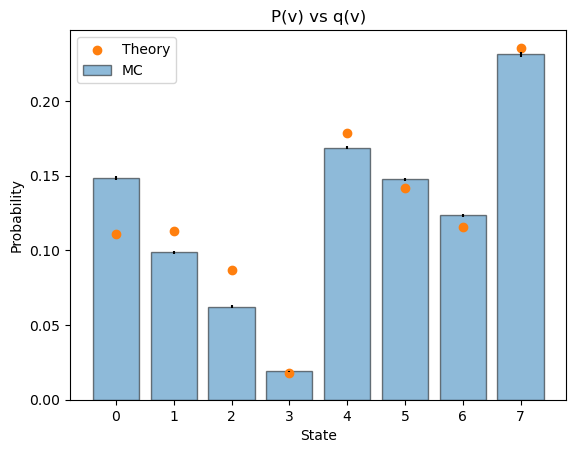

In [602]:
rbm_err = np.sqrt(pv / niter)
plt.bar(
    v_ints,
    np.sum(joint, axis=1),
    alpha=0.5,
    label="MC",
    edgecolor="black",
    yerr=rbm_err,
)
plt.scatter(v_ints, prob_dist, color="tab:orange", label="Theory")
plt.legend()
plt.xlabel("State")
plt.ylabel("Probability")
plt.title("P(v) vs q(v)")
plt.show()

In [657]:
circ = """3
H 0 
CNOT 0 1
P 1 0.45
H 2
CNOT 1 2
"""

niter = 100000
sample_size = 100000
batch_size = 64
alpha = 0.05
k = 1
nv = 3
nh = 7
nepoch = 1000
v_ints = np.arange(2**nv)

prob_dist = (np.abs(DiracToVec(runSim(circ))) ** 2).astype(np.float64)
samples = np.random.choice(range(0, 2**nv), p=prob_dist, size=sample_size)
rbm = RBM(nv, nh)
rbm.train(alpha, nepoch, batch_size, samples, k)
joint = rbm.joint(niter, k)
pv = np.sum(joint, axis=1)

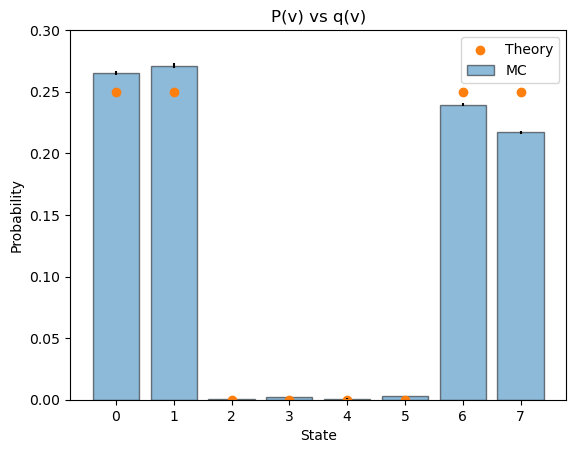

In [658]:
rbm_err = np.sqrt(pv / niter)
plt.bar(
    v_ints,
    np.sum(joint, axis=1),
    alpha=0.5,
    label="MC",
    edgecolor="black",
    yerr=rbm_err,
)
plt.scatter(v_ints, prob_dist, color="tab:orange", label="Theory")
plt.legend()
plt.xlabel("State")
plt.ylabel("Probability")
plt.title("P(v) vs q(v)")
plt.ylim(0, 0.3)
plt.show()